------------

# Task 1: Exploratory Data Analysis & Risk Profiling
## Project: Geldium Finance — Delinquency Prediction
### Consultant: Om Naik | Tata iQ Analytics Team
---
### Objective
Conduct a comprehensive EDA on Geldium's customer dataset to:
- Assess data quality and completeness
- Identify key risk factors for delinquency
- Prepare insights for predictive modeling

In [1]:
# ============================================================
# CELL 1: LIBRARY IMPORTS & DATA LOADING
# ============================================================

import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib
print(f"Backend: {matplotlib.get_backend()}")


# --- Display Settings ---
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# --- Load Dataset ---
# Navigate one level up from notebooks/ to reach data/raw/
data_path = os.path.join(
    os.path.dirname(os.getcwd()),
    'data', 'raw',
    'Delinquency_prediction_dataset.xlsx'
)

df = pd.read_excel(data_path)

# ============================================================
# FIRST LOOK
# ============================================================

print("=" * 60)
print("   GELDIUM FINANCE — DELINQUENCY DATASET: INSPECTION")
print("=" * 60)

print(f"\n📐 Shape      : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\n📋 Columns    :\n{df.columns.tolist()}")
print(f"\n🔍 Data Types :\n{df.dtypes}")
print(f"\n👀 First 5 Rows:\n{df.head()}")

Backend: inline
   GELDIUM FINANCE — DELINQUENCY DATASET: INSPECTION

📐 Shape      : 500 rows × 19 columns

📋 Columns    :
['Customer_ID', 'Age', 'Income', 'Credit_Score', 'Credit_Utilization', 'Missed_Payments', 'Delinquent_Account', 'Loan_Balance', 'Debt_to_Income_Ratio', 'Employment_Status', 'Account_Tenure', 'Credit_Card_Type', 'Location', 'Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6']

🔍 Data Types :
Customer_ID                 str
Age                       int64
Income                  float64
Credit_Score            float64
Credit_Utilization      float64
Missed_Payments           int64
Delinquent_Account        int64
Loan_Balance            float64
Debt_to_Income_Ratio    float64
Employment_Status           str
Account_Tenure            int64
Credit_Card_Type            str
Location                    str
Month_1                     str
Month_2                     str
Month_3                     str
Month_4                     str
Month_5                     

---------------------

## Cell 2: Statistical Summary & Missing Value Analysis
Assess data completeness and basic statistics for all features.

In [2]:
# ============================================================
# CELL 2: STATISTICAL SUMMARY & MISSING VALUE ANALYSIS
# ============================================================

print("=" * 60)
print("   STATISTICAL SUMMARY")
print("=" * 60)

# Descriptive statistics for numerical columns
print("\n📊 Numerical Features Summary:")
print(df.describe().T)

print("\n" + "=" * 60)
print("   MISSING VALUE ANALYSIS")
print("=" * 60)

# Count and percentage of missing values per column
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count' : missing_count,
    'Missing %'     : missing_pct,
    'Data Type'     : df.dtypes
}).sort_values('Missing %', ascending=False)

print(f"\n🔍 Missing Value Report:\n{missing_df}")
print(f"\n📐 Total Missing Cells : {df.isnull().sum().sum()}")
print(f"📐 Total Cells         : {df.shape[0] * df.shape[1]}")
print(f"📐 Overall Missing %   : {(df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100):.2f}%")

# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"\n🔁 Duplicate Rows      : {duplicates}")

# Check unique values in categorical columns
print("\n📋 Categorical Column Unique Values:")
cat_cols = ['Employment_Status', 'Credit_Card_Type', 
            'Location', 'Month_1', 'Month_2', 
            'Month_3', 'Month_4', 'Month_5', 'Month_6']

for col in cat_cols:
    print(f"   {col:25s}: {df[col].unique().tolist()}")

   STATISTICAL SUMMARY

📊 Numerical Features Summary:
                      count      mean      std      min      25%       50%  \
Age                  500.00     46.27    16.19    18.00    33.00     46.50   
Income               461.00 108379.89 53662.72 15404.00 62295.00 107658.00   
Credit_Score         498.00    577.72   168.88   301.00   418.25    586.00   
Credit_Utilization   500.00      0.49     0.20     0.05     0.36      0.49   
Missed_Payments      500.00      2.97     1.95     0.00     1.00      3.00   
Delinquent_Account   500.00      0.16     0.37     0.00     0.00      0.00   
Loan_Balance         471.00  48654.43 29395.54   612.00 23716.50  45776.00   
Debt_to_Income_Ratio 500.00      0.30     0.09     0.10     0.23      0.30   
Account_Tenure       500.00      9.74     5.92     0.00     5.00     10.00   

                           75%       max  
Age                      59.25     74.00  
Income               155734.00 199943.00  
Credit_Score            727.25    84

-------

## Cell 3: Data Cleaning — Fix Dirty Data
Fix Employment_Status inconsistencies, handle missing values,
and flag the Credit_Utilization anomaly.

In [3]:
# ============================================================
# CELL 3: DATA CLEANING
# ============================================================

# Work on a copy — NEVER modify raw data
df_clean = df.copy()

print("=" * 60)
print("   DATA CLEANING REPORT")
print("=" * 60)

# ------------------------------------------------------------
# FIX 1: Standardize Employment_Status
# ------------------------------------------------------------
print("\n🔧 FIX 1: Standardizing Employment_Status...")
print(f"   Before: {df_clean['Employment_Status'].unique().tolist()}")

employment_mapping = {
    'EMP'          : 'Employed',
    'employed'     : 'Employed',
    'Employed'     : 'Employed',
    'Self-employed': 'Self-Employed',
    'Unemployed'   : 'Unemployed',
    'retired'      : 'Retired'
}

df_clean['Employment_Status'] = df_clean['Employment_Status'].map(employment_mapping)
print(f"   After : {df_clean['Employment_Status'].unique().tolist()}")

# ------------------------------------------------------------
# FIX 2: Impute Missing Values with Median
# ------------------------------------------------------------
print("\n🔧 FIX 2: Imputing Missing Values with Median...")

for col in ['Income', 'Loan_Balance', 'Credit_Score']:
    median_val = df_clean[col].median()
    missing_before = df_clean[col].isnull().sum()
    df_clean[col] = df_clean[col].fillna(median_val)
    print(f"   {col:25s}: {missing_before} nulls filled with median = {median_val:,.2f}")

# ------------------------------------------------------------
# FIX 3: Flag Credit_Utilization Anomaly
# ------------------------------------------------------------
print("\n🔧 FIX 3: Investigating Credit_Utilization > 1.0...")

anomaly_mask = df_clean['Credit_Utilization'] > 1.0
anomaly_count = anomaly_mask.sum()
print(f"   Rows with Credit_Utilization > 1.0 : {anomaly_count}")

if anomaly_count > 0:
    print(f"   Capping values at 1.0 (100% utilization)")
    df_clean['Credit_Utilization'] = df_clean['Credit_Utilization'].clip(upper=1.0)
    print(f"   New Max Credit_Utilization: {df_clean['Credit_Utilization'].max():.4f}")

# ------------------------------------------------------------
# FIX 4: Encode Month Columns to Numeric
# ------------------------------------------------------------
print("\n🔧 FIX 4: Encoding Month Payment Columns to Numeric...")

payment_mapping = {
    'On-time' : 0,
    'Late'    : 1,
    'Missed'  : 2
}

month_cols = ['Month_1', 'Month_2', 'Month_3', 
              'Month_4', 'Month_5', 'Month_6']

for col in month_cols:
    df_clean[col] = df_clean[col].map(payment_mapping)

print(f"   Month columns encoded: {month_cols}")
print(f"   Encoding: On-time=0 | Late=1 | Missed=2")

# ------------------------------------------------------------
# VERIFICATION
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("   POST-CLEANING VERIFICATION")
print("=" * 60)
print(f"\n✅ Missing Values Remaining : {df_clean.isnull().sum().sum()}")
print(f"✅ Employment_Status Values : {df_clean['Employment_Status'].unique().tolist()}")
print(f"✅ Credit_Utilization Max   : {df_clean['Credit_Utilization'].max():.4f}")
print(f"✅ Month_1 Sample Values    : {df_clean['Month_1'].unique().tolist()}")
print(f"\n📐 Clean Dataset Shape      : {df_clean.shape}")

# Save cleaned dataset
output_path = os.path.join(
    os.path.dirname(os.getcwd()),
    'data', 'processed',
    'delinquency_cleaned.csv'
)
df_clean.to_csv(output_path, index=False)
print(f"\n💾 Cleaned dataset saved to: data/processed/delinquency_cleaned.csv")

   DATA CLEANING REPORT

🔧 FIX 1: Standardizing Employment_Status...
   Before: ['EMP', 'Self-employed', 'Unemployed', 'employed', 'Employed', 'retired']
   After : ['Employed', 'Self-Employed', 'Unemployed', 'Retired']

🔧 FIX 2: Imputing Missing Values with Median...
   Income                   : 39 nulls filled with median = 107,658.00
   Loan_Balance             : 29 nulls filled with median = 45,776.00
   Credit_Score             : 2 nulls filled with median = 586.00

🔧 FIX 3: Investigating Credit_Utilization > 1.0...
   Rows with Credit_Utilization > 1.0 : 4
   Capping values at 1.0 (100% utilization)
   New Max Credit_Utilization: 1.0000

🔧 FIX 4: Encoding Month Payment Columns to Numeric...
   Month columns encoded: ['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6']
   Encoding: On-time=0 | Late=1 | Missed=2

   POST-CLEANING VERIFICATION

✅ Missing Values Remaining : 0
✅ Employment_Status Values : ['Employed', 'Self-Employed', 'Unemployed', 'Retired']
✅ Credit_U

----------

## Cell 4: Target Variable Analysis & Class Imbalance
Analyze the distribution of our target variable: Delinquent_Account.
Understanding class balance is critical before any modeling.

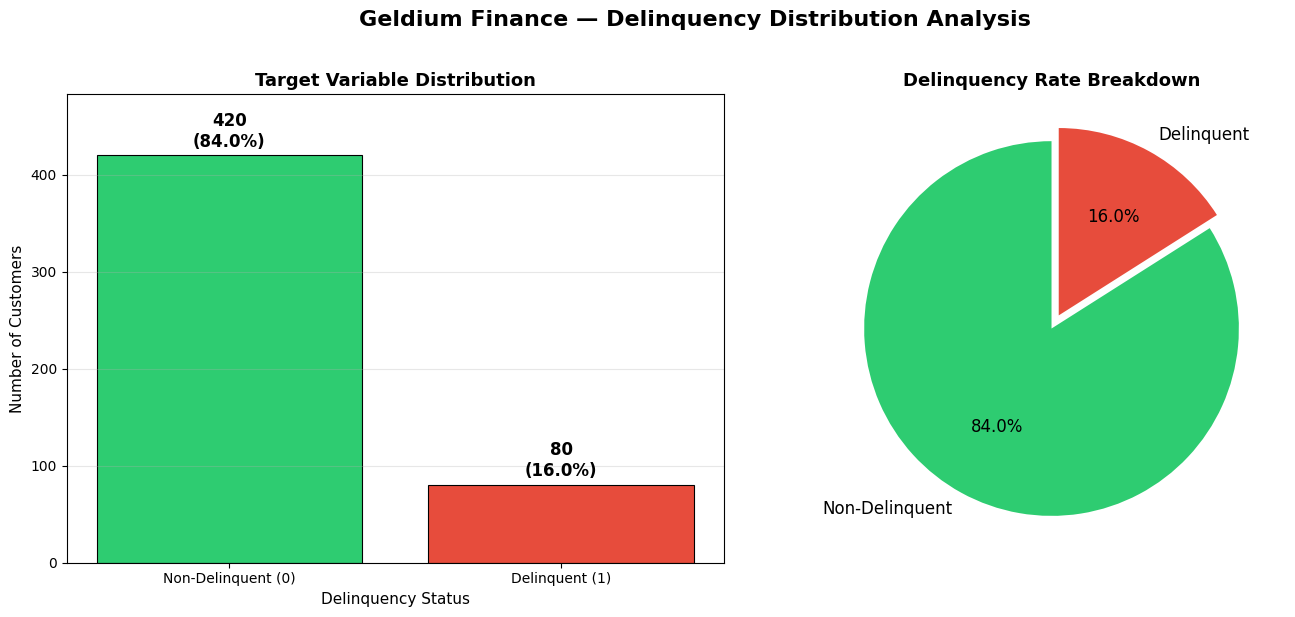

💾 Figure saved to: reports/figures/target_distribution.png

   TARGET VARIABLE SUMMARY

📊 Total Customers        : 500
✅ Non-Delinquent (0)     : 420 (84.0%)
🚨 Delinquent (1)         : 80 (16.0%)

⚠️  Class Imbalance Ratio  : 5.2:1
⚠️  Imbalance Flag         : YES — Requires SMOTE or class weighting in Task 2

💼 Business Insight:
   Geldium has a 16.0% delinquency rate.
   That means 80 out of 500 customers
   are currently at risk of default.
   Industry average credit card delinquency: ~2-5%
   Geldium's rate suggests elevated portfolio risk.


In [4]:
# ============================================================
# CELL 4: TARGET VARIABLE ANALYSIS & CLASS IMBALANCE
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'Geldium Finance — Delinquency Distribution Analysis',
    fontsize=16, fontweight='bold', y=1.02
)

# ------------------------------------------------------------
# PLOT 1: Class Distribution — Bar Chart
# ------------------------------------------------------------
target_counts = df_clean['Delinquent_Account'].value_counts()
target_pct = df_clean['Delinquent_Account'].value_counts(normalize=True) * 100

colors = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(
    ['Non-Delinquent (0)', 'Delinquent (1)'],
    target_counts.values,
    color=colors,
    edgecolor='black',
    linewidth=0.8
)

# Add value labels on bars
for bar, count, pct in zip(bars, target_counts.values, target_pct.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f'{count}\n({pct:.1f}%)',
        ha='center', va='bottom',
        fontweight='bold', fontsize=12
    )

axes[0].set_title('Target Variable Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Customers', fontsize=11)
axes[0].set_xlabel('Delinquency Status', fontsize=11)
axes[0].set_ylim(0, max(target_counts.values) * 1.15)
axes[0].grid(axis='y', alpha=0.3)

# ------------------------------------------------------------
# PLOT 2: Pie Chart
# ------------------------------------------------------------
axes[1].pie(
    target_counts.values,
    labels=['Non-Delinquent', 'Delinquent'],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    explode=(0, 0.08),
    textprops={'fontsize': 12}
)
axes[1].set_title('Delinquency Rate Breakdown', fontsize=13, fontweight='bold')

plt.tight_layout()

# Save figure
fig_path = os.path.join(
    os.path.dirname(os.getcwd()),
    'reports', 'figures',
    'target_distribution.png'
)
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 Figure saved to: reports/figures/target_distribution.png")

# ------------------------------------------------------------
# BUSINESS SUMMARY
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("   TARGET VARIABLE SUMMARY")
print("=" * 60)
print(f"\n📊 Total Customers        : {len(df_clean):,}")
print(f"✅ Non-Delinquent (0)     : {target_counts[0]:,} ({target_pct[0]:.1f}%)")
print(f"🚨 Delinquent (1)         : {target_counts[1]:,} ({target_pct[1]:.1f}%)")
print(f"\n⚠️  Class Imbalance Ratio  : {target_counts[0]/target_counts[1]:.1f}:1")
print(f"⚠️  Imbalance Flag         : {'YES — Requires SMOTE or class weighting in Task 2' if target_pct[1] < 30 else 'NO — Balanced dataset'}")

print("\n💼 Business Insight:")
print(f"   Geldium has a {target_pct[1]:.1f}% delinquency rate.")
print(f"   That means {target_counts[1]} out of {len(df_clean)} customers")
print(f"   are currently at risk of default.")
print(f"   Industry average credit card delinquency: ~2-5%")
print(f"   Geldium's rate suggests elevated portfolio risk.")

---------------------

## Cell 5: Numerical Features Distribution Analysis
Analyze the distribution of all numerical risk factors
to identify patterns, skewness, and outliers.

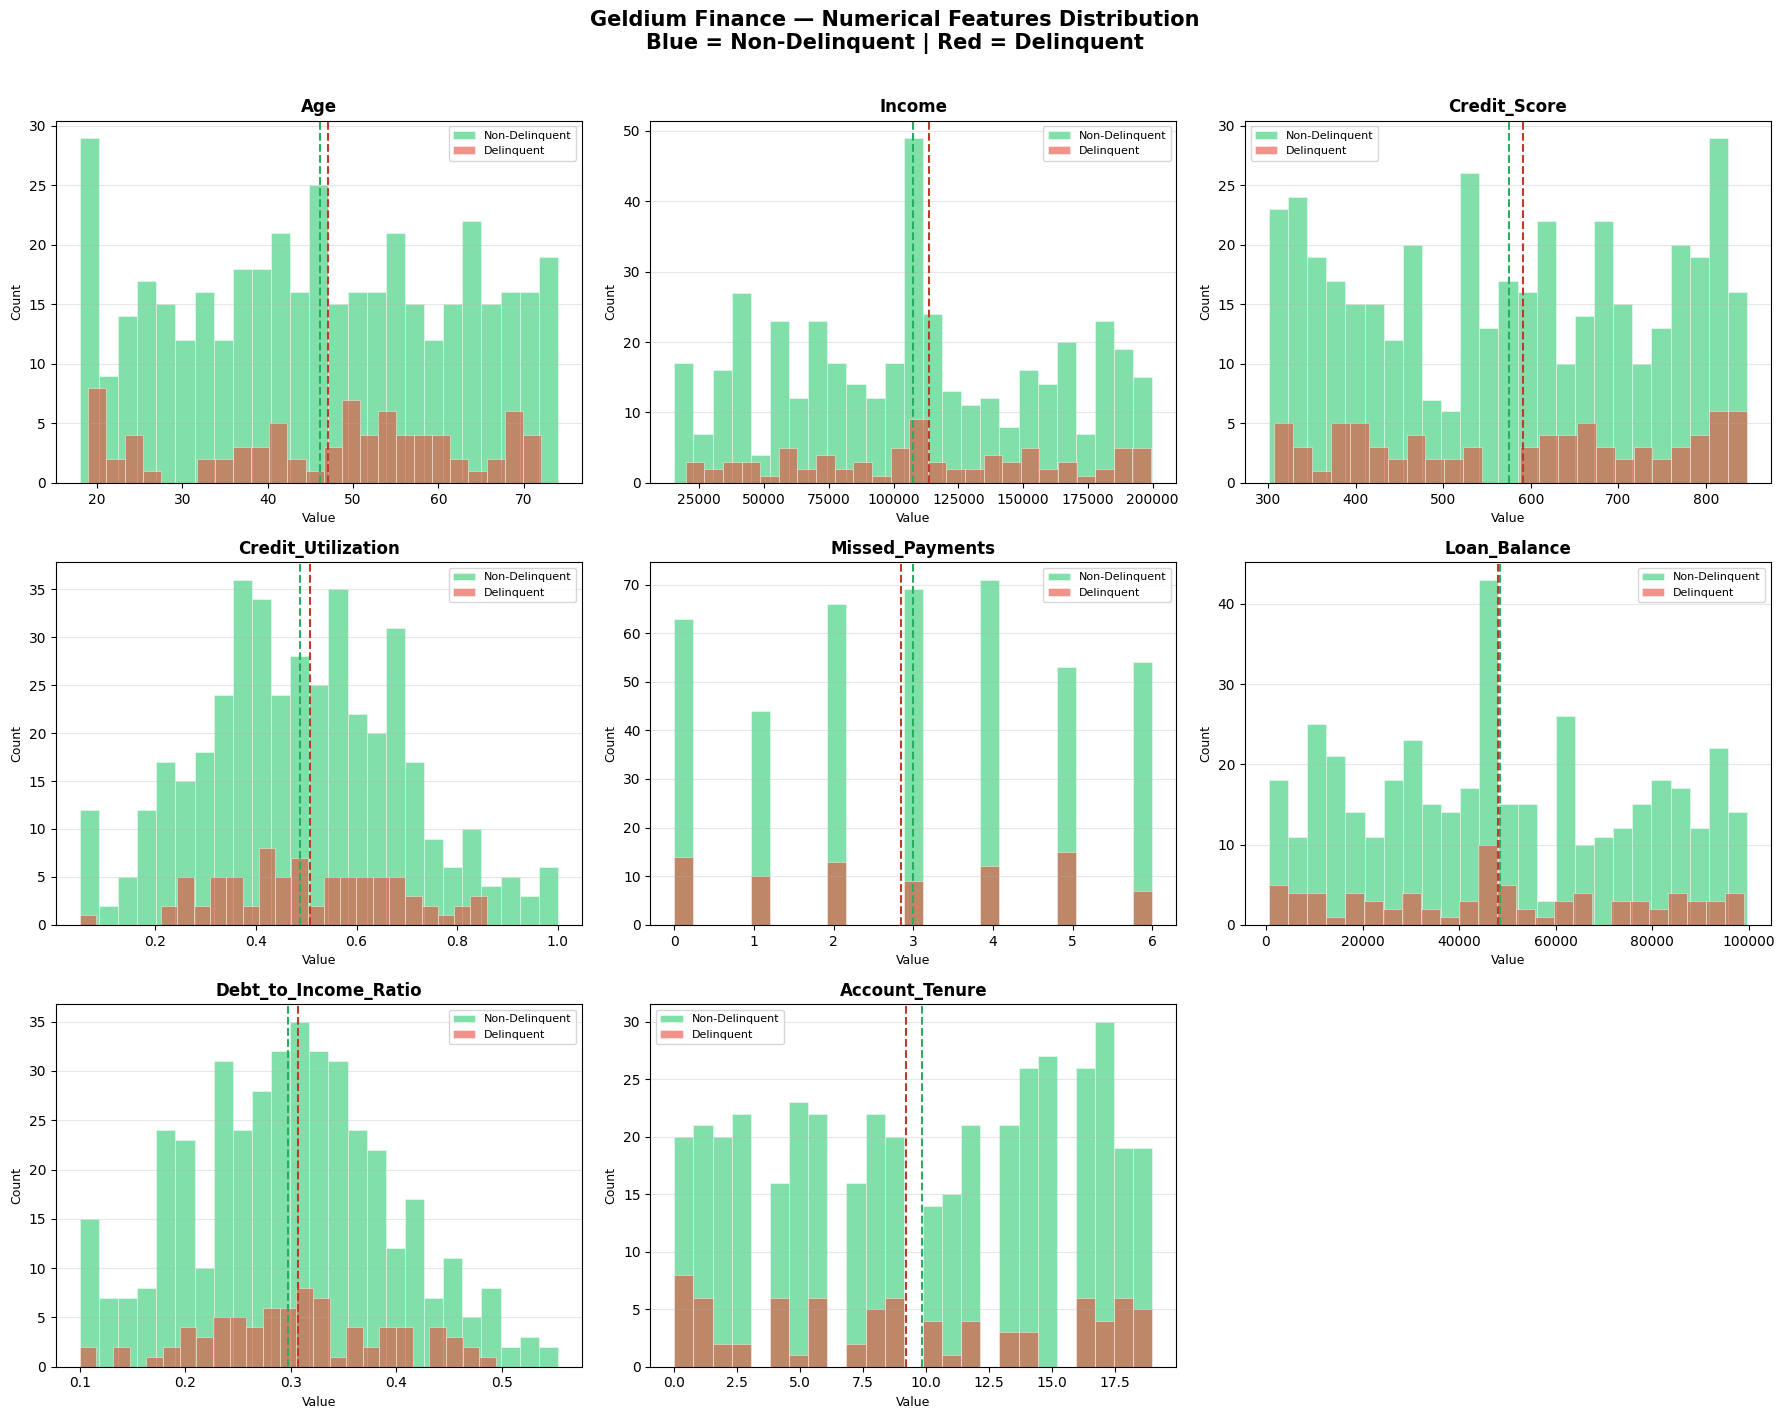

💾 Figure saved to: reports/figures/numerical_distributions.png

   NUMERICAL FEATURES — MEAN BY DELINQUENCY STATUS

                      Non-Delinquent (0)  Delinquent (1)  Difference %
Age                                46.11           47.10          2.20
Income                         107335.36       113511.76          5.80
Credit_Score                      575.20          591.15          2.80
Credit_Utilization                  0.49            0.51          3.80
Missed_Payments                     2.99            2.85         -4.70
Loan_Balance                    48555.14        48132.29         -0.90
Debt_to_Income_Ratio                0.30            0.31          3.00
Account_Tenure                      9.84            9.20         -6.50

💼 Key Risk Signals:


In [5]:
# ============================================================
# CELL 5: NUMERICAL FEATURES DISTRIBUTION ANALYSIS
# ============================================================

numerical_cols = [
    'Age', 'Income', 'Credit_Score',
    'Credit_Utilization', 'Missed_Payments',
    'Loan_Balance', 'Debt_to_Income_Ratio',
    'Account_Tenure'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle(
    'Geldium Finance — Numerical Features Distribution\n'
    'Blue = Non-Delinquent | Red = Delinquent',
    fontsize=15, fontweight='bold', y=1.01
)

axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    # Plot distribution split by delinquency status
    for status, color, label in zip(
        [0, 1],
        ['#2ecc71', '#e74c3c'],
        ['Non-Delinquent', 'Delinquent']
    ):
        subset = df_clean[df_clean['Delinquent_Account'] == status][col]
        axes[idx].hist(
            subset,
            bins=25,
            alpha=0.6,
            color=color,
            label=label,
            edgecolor='white',
            linewidth=0.5
        )

    axes[idx].set_title(col, fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Value', fontsize=9)
    axes[idx].set_ylabel('Count', fontsize=9)
    axes[idx].legend(fontsize=8)
    axes[idx].grid(axis='y', alpha=0.3)

    # Add mean lines
    mean_non_del = df_clean[df_clean['Delinquent_Account']==0][col].mean()
    mean_del = df_clean[df_clean['Delinquent_Account']==1][col].mean()
    axes[idx].axvline(mean_non_del, color='#27ae60', linestyle='--', linewidth=1.5)
    axes[idx].axvline(mean_del, color='#c0392b', linestyle='--', linewidth=1.5)

# Hide the last empty subplot
axes[-1].set_visible(False)

plt.tight_layout()

fig_path = os.path.join(
    os.path.dirname(os.getcwd()),
    'reports', 'figures',
    'numerical_distributions.png'
)
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print("💾 Figure saved to: reports/figures/numerical_distributions.png")

# ------------------------------------------------------------
# STATISTICAL SUMMARY BY DELINQUENCY STATUS
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("   NUMERICAL FEATURES — MEAN BY DELINQUENCY STATUS")
print("=" * 60)

summary = df_clean.groupby('Delinquent_Account')[numerical_cols].mean().T
summary.columns = ['Non-Delinquent (0)', 'Delinquent (1)']
summary['Difference %'] = (
    (summary['Delinquent (1)'] - summary['Non-Delinquent (0)'])
    / summary['Non-Delinquent (0)'] * 100
).round(1)

print(f"\n{summary.to_string()}")

print("\n💼 Key Risk Signals:")
for col in numerical_cols:
    non_del_mean = df_clean[df_clean['Delinquent_Account']==0][col].mean()
    del_mean = df_clean[df_clean['Delinquent_Account']==1][col].mean()
    diff_pct = ((del_mean - non_del_mean) / non_del_mean * 100)
    direction = "higher" if diff_pct > 0 else "lower"
    if abs(diff_pct) > 10:
        print(f"   🚨 {col:25s}: Delinquents have {abs(diff_pct):.1f}% {direction} values")

-------------------------

## Cell 6: Correlation Analysis & Heatmap
Identify relationships between all numerical features
and the target variable to find true predictors.


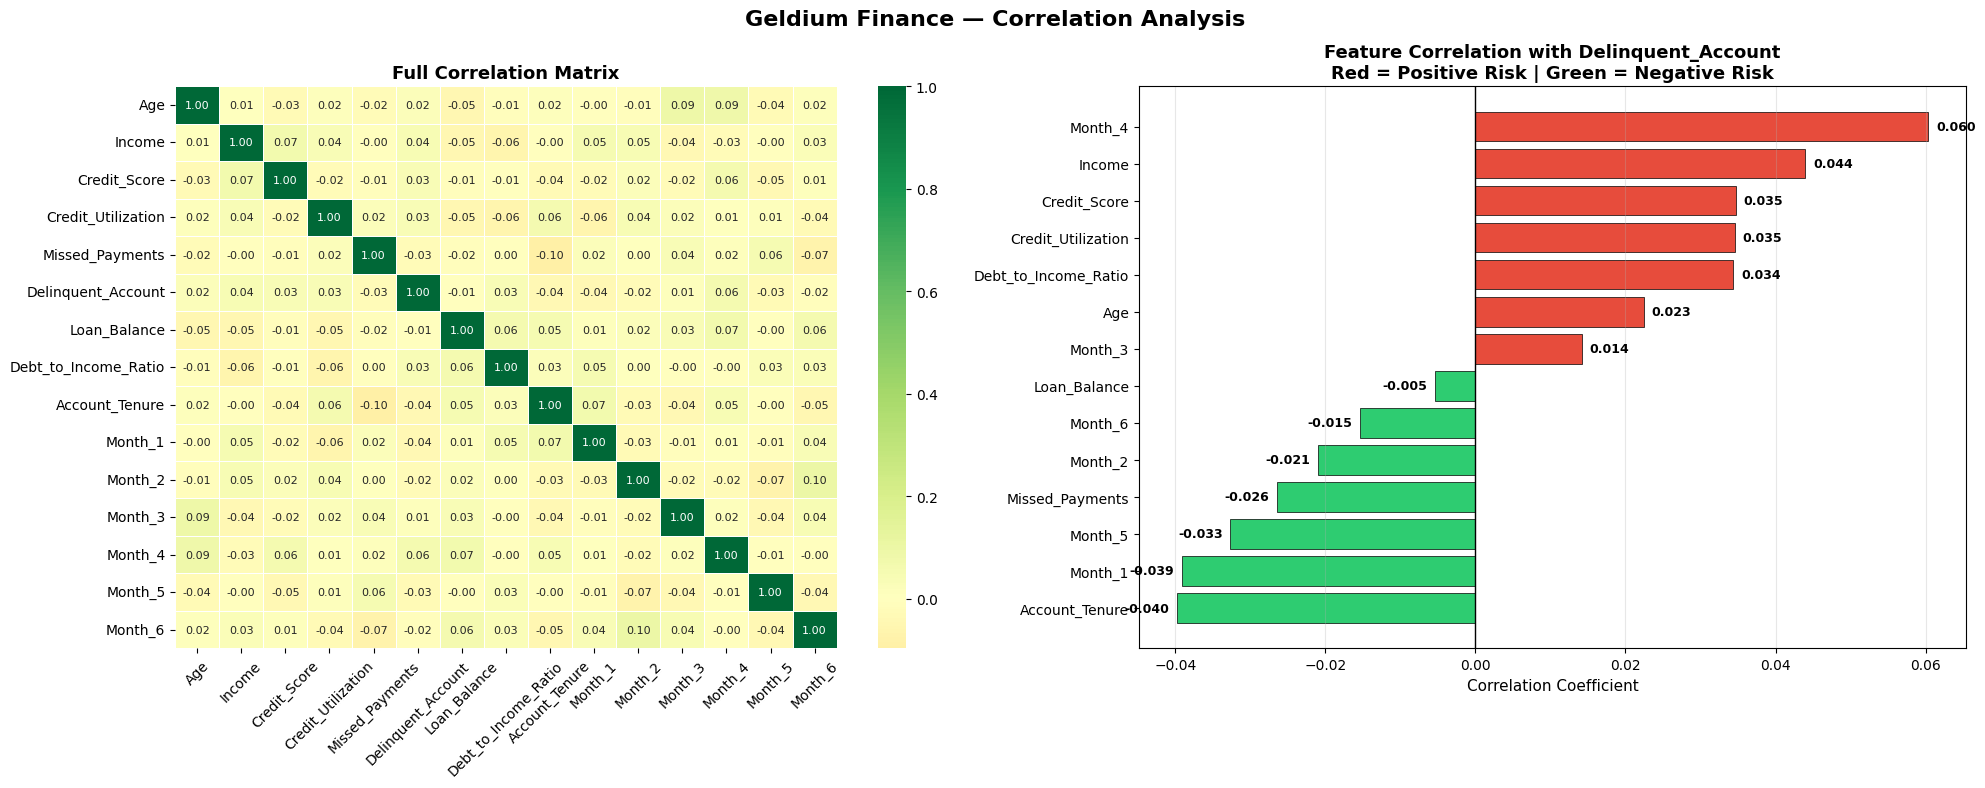

💾 Figure saved to: reports/figures/correlation_heatmap.png

   FEATURE CORRELATION WITH DELINQUENCY (RANKED)

Feature                    Correlation Strength             Direction
----------------------------------------------------------------------
Month_4                         0.0604 WEAK                 ⬆️  Risk Increases
Income                          0.0440 WEAK                 ⬆️  Risk Increases
Account_Tenure                 -0.0398 WEAK                 ⬇️  Risk Decreases
Month_1                        -0.0391 WEAK                 ⬇️  Risk Decreases
Credit_Score                    0.0347 WEAK                 ⬆️  Risk Increases
Credit_Utilization              0.0346 WEAK                 ⬆️  Risk Increases
Debt_to_Income_Ratio            0.0344 WEAK                 ⬆️  Risk Increases
Month_5                        -0.0327 WEAK                 ⬇️  Risk Decreases
Missed_Payments                -0.0265 WEAK                 ⬇️  Risk Decreases
Age                             0.0225

In [6]:
# ============================================================
# CELL 6: CORRELATION ANALYSIS & HEATMAP
# ============================================================

# --- Prepare numeric dataframe including month columns ---
numeric_df = df_clean.select_dtypes(include=[np.number])

# --- Compute correlation matrix ---
corr_matrix = numeric_df.corr()

# --- Full Heatmap ---
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle(
    'Geldium Finance — Correlation Analysis',
    fontsize=16, fontweight='bold'
)

# Plot 1: Full correlation heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 8},
    ax=axes[0]
)
axes[0].set_title(
    'Full Correlation Matrix',
    fontsize=13, fontweight='bold'
)
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# Plot 2: Correlation with Target Variable Only
target_corr = corr_matrix['Delinquent_Account'].drop(
    'Delinquent_Account'
).sort_values(ascending=True)

colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in target_corr.values]

bars = axes[1].barh(
    target_corr.index,
    target_corr.values,
    color=colors,
    edgecolor='black',
    linewidth=0.5
)

# Add value labels
for bar, val in zip(bars, target_corr.values):
    axes[1].text(
        val + (0.001 if val >= 0 else -0.001),
        bar.get_y() + bar.get_height() / 2,
        f'{val:.3f}',
        va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=9, fontweight='bold'
    )

axes[1].set_title(
    'Feature Correlation with Delinquent_Account\n'
    'Red = Positive Risk | Green = Negative Risk',
    fontsize=13, fontweight='bold'
)
axes[1].set_xlabel('Correlation Coefficient', fontsize=11)
axes[1].axvline(x=0, color='black', linewidth=1)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()

fig_path = os.path.join(
    os.path.dirname(os.getcwd()),
    'reports', 'figures',
    'correlation_heatmap.png'
)
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print("💾 Figure saved to: reports/figures/correlation_heatmap.png")

# --- Print Correlation Rankings ---
print("\n" + "=" * 60)
print("   FEATURE CORRELATION WITH DELINQUENCY (RANKED)")
print("=" * 60)

target_corr_sorted = corr_matrix['Delinquent_Account'].drop(
    'Delinquent_Account'
).sort_values(key=abs, ascending=False)

print(f"\n{'Feature':<25} {'Correlation':>12} {'Strength':<20} {'Direction'}")
print("-" * 70)

for feature, corr in target_corr_sorted.items():
    strength = (
        'STRONG'   if abs(corr) > 0.3 else
        'MODERATE' if abs(corr) > 0.1 else
        'WEAK'
    )
    direction = '⬆️  Risk Increases' if corr > 0 else '⬇️  Risk Decreases'
    print(f"{feature:<25} {corr:>12.4f} {strength:<20} {direction}")

print("\n💼 Business Insight:")
print("   Features with |correlation| > 0.1 are meaningful predictors")
print("   Features with |correlation| > 0.3 are strong predictors")

------------------

## Cell 7: Categorical Features & Risk Profiling
Analyze delinquency rates across Employment Status,
Credit Card Type, and Location segments.

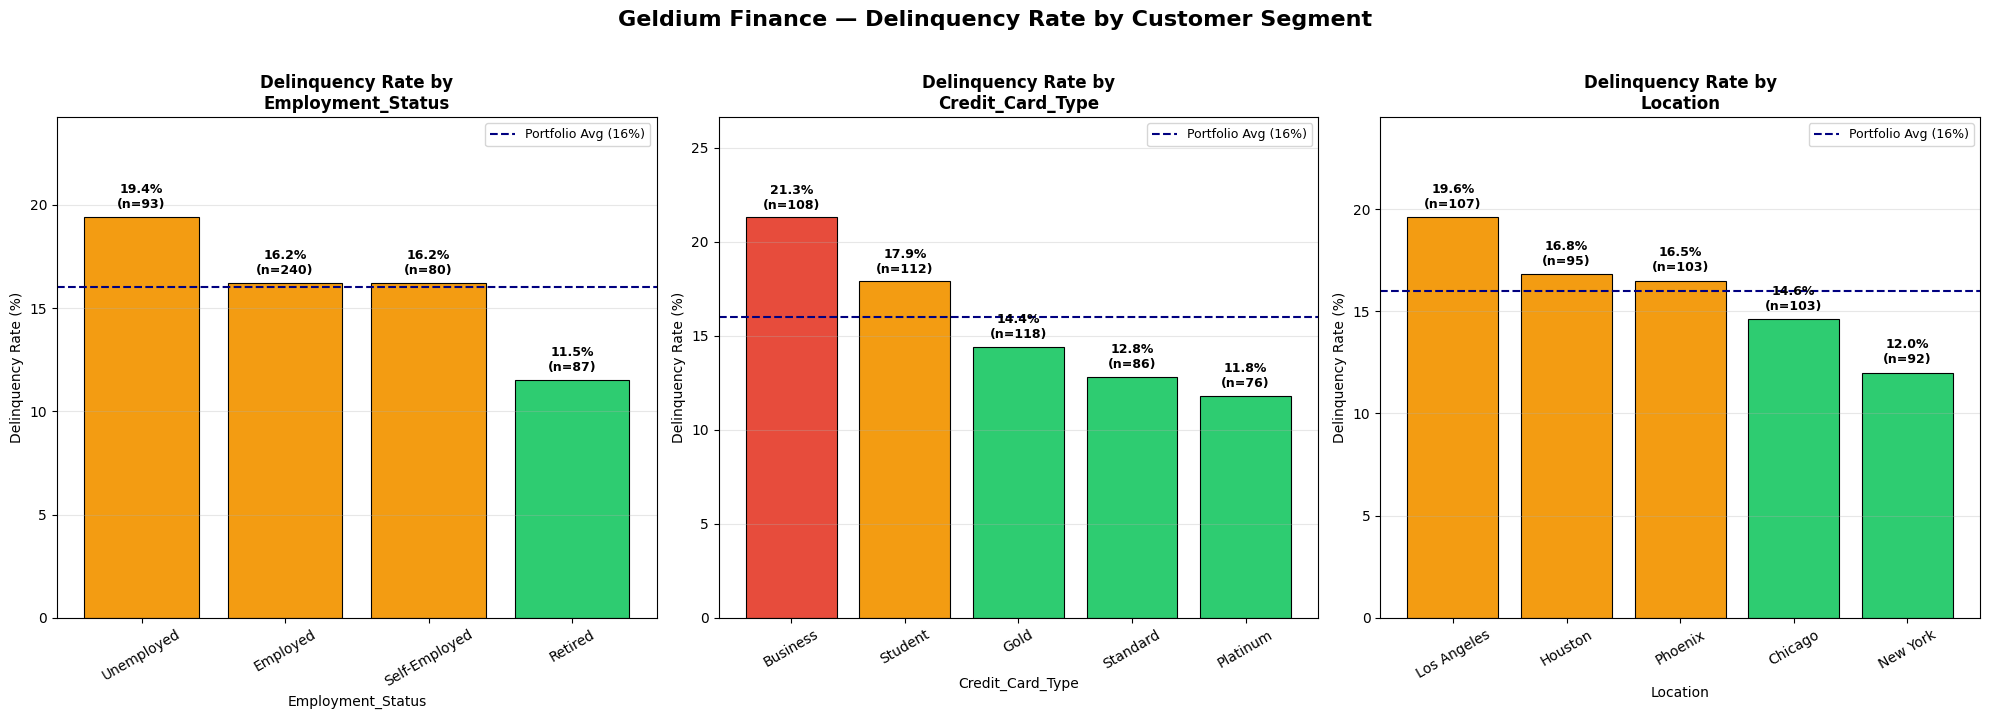

💾 Figure saved to: reports/figures/categorical_risk_profiling.png

   SEGMENT RISK PROFILING — DETAILED BREAKDOWN

📊 Employment_Status:
Category                Total   Delinquent   Rate % Risk Level
------------------------------------------------------------
Unemployed                 93           18    19.4% 🟡 MEDIUM
Employed                  240           39    16.2% 🟡 MEDIUM
Self-Employed              80           13    16.2% 🟡 MEDIUM
Retired                    87           10    11.5% 🟢 LOW

📊 Credit_Card_Type:
Category                Total   Delinquent   Rate % Risk Level
------------------------------------------------------------
Business                  108           23    21.3% 🔴 HIGH
Student                   112           20    17.9% 🟡 MEDIUM
Gold                      118           17    14.4% 🟢 LOW
Standard                   86           11    12.8% 🟢 LOW
Platinum                   76            9    11.8% 🟢 LOW

📊 Location:
Category                Total   Delinquent   Ra

In [7]:
# ============================================================
# CELL 7: CATEGORICAL FEATURES RISK PROFILING
# ============================================================

categorical_features = [
    'Employment_Status',
    'Credit_Card_Type',
    'Location'
]

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle(
    'Geldium Finance — Delinquency Rate by Customer Segment',
    fontsize=16, fontweight='bold', y=1.02
)

for idx, col in enumerate(categorical_features):

    # Calculate delinquency rate per category
    risk_profile = df_clean.groupby(col).agg(
        Total=('Delinquent_Account', 'count'),
        Delinquent=('Delinquent_Account', 'sum')
    ).reset_index()

    risk_profile['Delinquency_Rate'] = (
        risk_profile['Delinquent'] / risk_profile['Total'] * 100
    ).round(1)

    risk_profile = risk_profile.sort_values(
        'Delinquency_Rate', ascending=False
    )

    # Color bars by risk level
    colors = [
        '#e74c3c' if rate > 20 else
        '#f39c12' if rate > 15 else
        '#2ecc71'
        for rate in risk_profile['Delinquency_Rate']
    ]

    bars = axes[idx].bar(
        risk_profile[col],
        risk_profile['Delinquency_Rate'],
        color=colors,
        edgecolor='black',
        linewidth=0.8
    )

    # Add value labels
    for bar, rate, total in zip(
        bars,
        risk_profile['Delinquency_Rate'],
        risk_profile['Total']
    ):
        axes[idx].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f'{rate}%\n(n={total})',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold'
        )

    # Add industry average line
    axes[idx].axhline(
        y=16.0,
        color='navy',
        linestyle='--',
        linewidth=1.5,
        label='Portfolio Avg (16%)'
    )

    axes[idx].set_title(
        f'Delinquency Rate by\n{col}',
        fontsize=12, fontweight='bold'
    )
    axes[idx].set_ylabel('Delinquency Rate (%)', fontsize=10)
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].tick_params(axis='x', rotation=30)
    axes[idx].set_ylim(0, max(risk_profile['Delinquency_Rate']) * 1.25)
    axes[idx].legend(fontsize=9)
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()

fig_path = os.path.join(
    os.path.dirname(os.getcwd()),
    'reports', 'figures',
    'categorical_risk_profiling.png'
)
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print("💾 Figure saved to: reports/figures/categorical_risk_profiling.png")

# --- Detailed Risk Table ---
print("\n" + "=" * 60)
print("   SEGMENT RISK PROFILING — DETAILED BREAKDOWN")
print("=" * 60)

for col in categorical_features:
    risk_profile = df_clean.groupby(col).agg(
        Total=('Delinquent_Account', 'count'),
        Delinquent=('Delinquent_Account', 'sum')
    ).reset_index()
    risk_profile['Delinquency_Rate_%'] = (
        risk_profile['Delinquent'] / risk_profile['Total'] * 100
    ).round(1)
    risk_profile = risk_profile.sort_values(
        'Delinquency_Rate_%', ascending=False
    )

    print(f"\n📊 {col}:")
    print(f"{'Category':<20} {'Total':>8} {'Delinquent':>12} {'Rate %':>8} {'Risk Level'}")
    print("-" * 60)

    for _, row in risk_profile.iterrows():
        risk_level = (
            '🔴 HIGH'   if row['Delinquency_Rate_%'] > 20 else
            '🟡 MEDIUM' if row['Delinquency_Rate_%'] > 15 else
            '🟢 LOW'
        )
        print(
            f"{str(row[col]):<20} "
            f"{int(row['Total']):>8} "
            f"{int(row['Delinquent']):>12} "
            f"{row['Delinquency_Rate_%']:>7.1f}% "
            f"{risk_level}"
        )

--------------------------

## Cell 8: Payment Behaviour Analysis (Month_1 to Month_6)
Analyze 6-month payment history patterns to identify
the strongest behavioural predictors of delinquency.

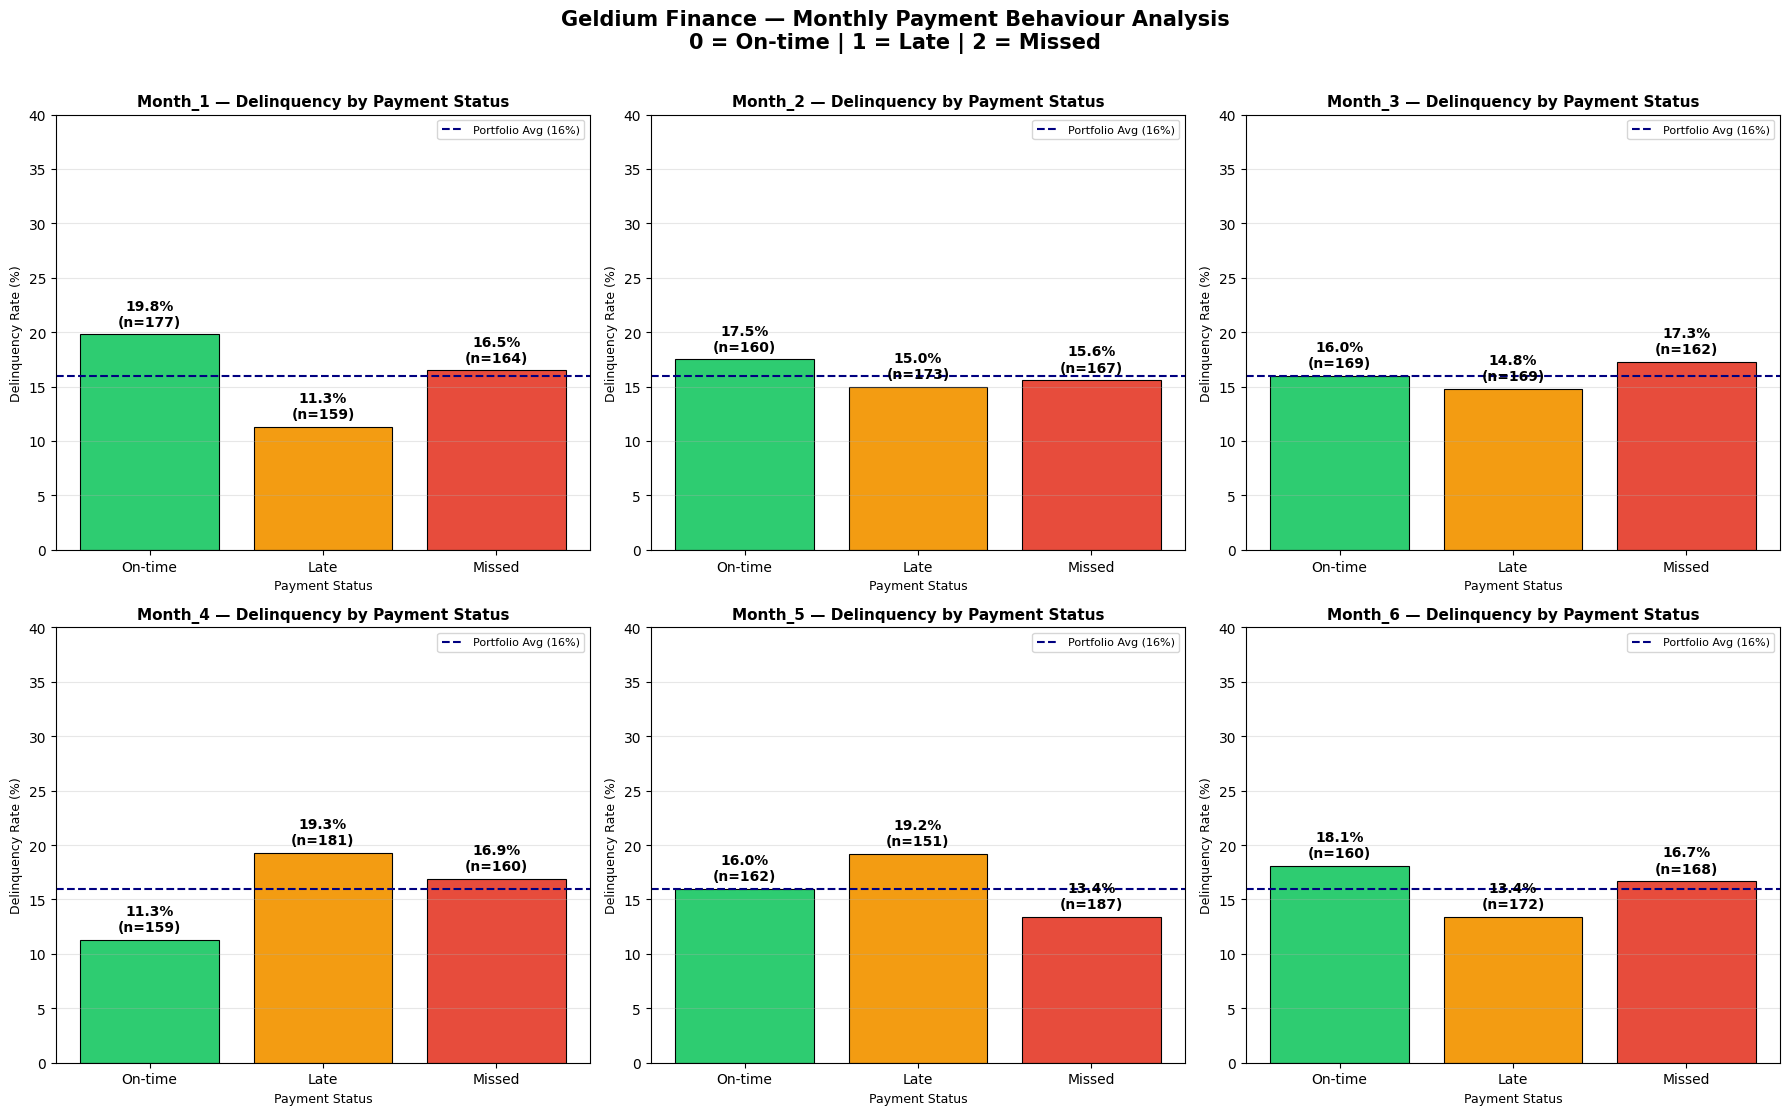

💾 Figure saved to: reports/figures/payment_behaviour_analysis.png

   PAYMENT BEHAVIOUR — DELINQUENCY RATE SUMMARY

📅 Month_1:
   On-time   :  19.8% delinquent (n=177)
   Late      :  11.3% delinquent (n=159)
   Missed    :  16.5% delinquent (n=164)

📅 Month_2:
   On-time   :  17.5% delinquent (n=160)
   Late      :  15.0% delinquent (n=173)
   Missed    :  15.6% delinquent (n=167)

📅 Month_3:
   On-time   :  16.0% delinquent (n=169)
   Late      :  14.8% delinquent (n=169)
   Missed    :  17.3% delinquent (n=162)

📅 Month_4:
   On-time   :  11.3% delinquent (n=159)
   Late      :  19.3% delinquent (n=181)
   Missed    :  16.9% delinquent (n=160)

📅 Month_5:
   On-time   :  16.0% delinquent (n=162)
   Late      :  19.2% delinquent (n=151)
   Missed    :  13.4% delinquent (n=187)

📅 Month_6:
   On-time   :  18.1% delinquent (n=160)
   Late      :  13.4% delinquent (n=172)
   Missed    :  16.7% delinquent (n=168)

   TOTAL MISSED PAYMENTS ACROSS 6 MONTHS — RISK PROFILE

  Months Missed  

In [8]:
# ============================================================
# CELL 8: PAYMENT BEHAVIOUR ANALYSIS — MONTH 1 TO MONTH 6
# ============================================================

month_cols = ['Month_1', 'Month_2', 'Month_3',
              'Month_4', 'Month_5', 'Month_6']

# --- Plot 1: Payment behaviour distribution per month ---
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(
    'Geldium Finance — Monthly Payment Behaviour Analysis\n'
    '0 = On-time | 1 = Late | 2 = Missed',
    fontsize=15, fontweight='bold', y=1.01
)
axes = axes.flatten()

payment_labels = {0: 'On-time', 1: 'Late', 2: 'Missed'}
payment_colors = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c'}

for idx, col in enumerate(month_cols):
    # Delinquency rate per payment status per month
    month_risk = df_clean.groupby(col).agg(
        Total=('Delinquent_Account', 'count'),
        Delinquent=('Delinquent_Account', 'sum')
    ).reset_index()
    month_risk['Delinquency_Rate'] = (
        month_risk['Delinquent'] / month_risk['Total'] * 100
    ).round(1)
    month_risk['Payment_Label'] = month_risk[col].map(payment_labels)
    month_risk['Color'] = month_risk[col].map(payment_colors)

    bars = axes[idx].bar(
        month_risk['Payment_Label'],
        month_risk['Delinquency_Rate'],
        color=month_risk['Color'],
        edgecolor='black',
        linewidth=0.8
    )

    for bar, rate, total in zip(
        bars,
        month_risk['Delinquency_Rate'],
        month_risk['Total']
    ):
        axes[idx].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{rate}%\n(n={total})',
            ha='center', va='bottom',
            fontsize=10, fontweight='bold'
        )

    axes[idx].axhline(
        y=16.0, color='navy',
        linestyle='--', linewidth=1.5,
        label='Portfolio Avg (16%)'
    )
    axes[idx].set_title(
        f'{col} — Delinquency by Payment Status',
        fontsize=11, fontweight='bold'
    )
    axes[idx].set_ylabel('Delinquency Rate (%)', fontsize=9)
    axes[idx].set_xlabel('Payment Status', fontsize=9)
    axes[idx].set_ylim(0, 40)
    axes[idx].legend(fontsize=8)
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
fig_path = os.path.join(
    os.path.dirname(os.getcwd()),
    'reports', 'figures',
    'payment_behaviour_analysis.png'
)
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print("💾 Figure saved to: reports/figures/payment_behaviour_analysis.png")

# --- Payment Behaviour Summary Table ---
print("\n" + "=" * 60)
print("   PAYMENT BEHAVIOUR — DELINQUENCY RATE SUMMARY")
print("=" * 60)

for col in month_cols:
    month_risk = df_clean.groupby(col).agg(
        Total=('Delinquent_Account', 'count'),
        Delinquent=('Delinquent_Account', 'sum')
    ).reset_index()
    month_risk['Rate_%'] = (
        month_risk['Delinquent'] / month_risk['Total'] * 100
    ).round(1)
    month_risk['Label'] = month_risk[col].map(payment_labels)
    print(f"\n📅 {col}:")
    for _, row in month_risk.iterrows():
        print(f"   {str(row['Label']):<10}: {row['Rate_%']:>5.1f}% delinquent (n={int(row['Total'])})")

# --- Missed Payment Counter Feature ---
print("\n" + "=" * 60)
print("   TOTAL MISSED PAYMENTS ACROSS 6 MONTHS — RISK PROFILE")
print("=" * 60)

df_clean['Total_Missed_6M'] = (
    df_clean[month_cols] == 2
).sum(axis=1)

missed_risk = df_clean.groupby('Total_Missed_6M').agg(
    Total=('Delinquent_Account', 'count'),
    Delinquent=('Delinquent_Account', 'sum')
).reset_index()
missed_risk['Rate_%'] = (
    missed_risk['Delinquent'] / missed_risk['Total'] * 100
).round(1)

print(f"\n{'Months Missed':>15} {'Total':>8} {'Delinquent':>12} {'Rate %':>8}")
print("-" * 50)
for _, row in missed_risk.iterrows():
    bar = '█' * int(row['Rate_%'] // 2)
    print(
        f"{int(row['Total_Missed_6M']):>15} "
        f"{int(row['Total']):>8} "
        f"{int(row['Delinquent']):>12} "
        f"{row['Rate_%']:>7.1f}% {bar}"
    )

-------------------

## Cell 9: EDA Summary — Risk Indicator Dashboard
Consolidate all findings into a final visual summary
for the EDA report submission.

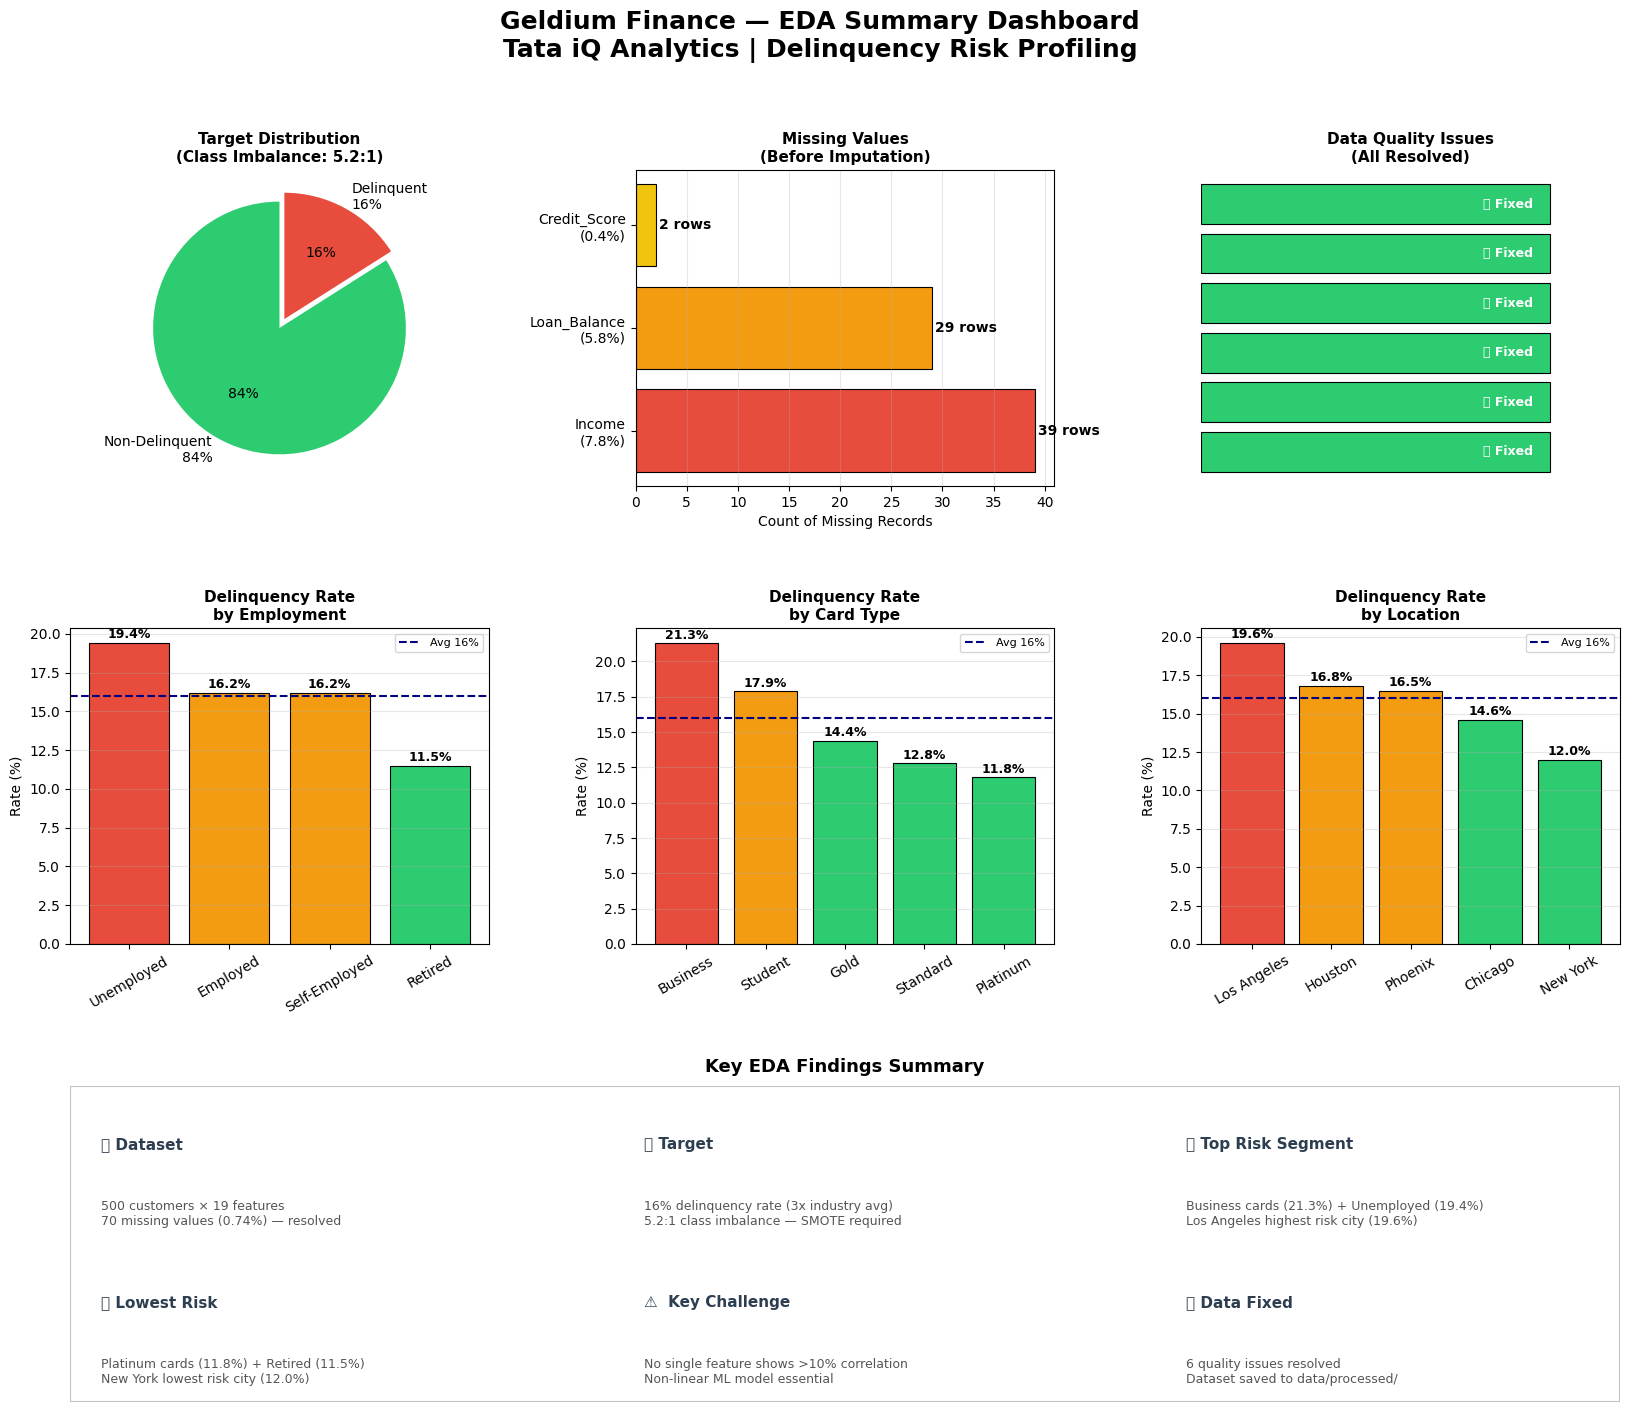

💾 Figure saved to: reports/figures/eda_summary_dashboard.png

✅ EDA COMPLETE — All figures saved to reports/figures/
📋 Ready to compile EDA Summary Report


In [9]:
# ============================================================
# CELL 9: COMPREHENSIVE EDA SUMMARY DASHBOARD
# ============================================================

fig = plt.figure(figsize=(20, 16))
fig.suptitle(
    'Geldium Finance — EDA Summary Dashboard\n'
    'Tata iQ Analytics | Delinquency Risk Profiling',
    fontsize=18, fontweight='bold', y=0.98
)

# --- Layout Grid ---
gs = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])
ax7 = fig.add_subplot(gs[2, :])

# ── PLOT 1: Target Distribution ──────────────────────────────
target_counts = df_clean['Delinquent_Account'].value_counts()
ax1.pie(
    target_counts.values,
    labels=['Non-Delinquent\n84%', 'Delinquent\n16%'],
    colors=['#2ecc71', '#e74c3c'],
    autopct='%1.0f%%',
    startangle=90,
    explode=(0, 0.08)
)
ax1.set_title('Target Distribution\n(Class Imbalance: 5.2:1)',
              fontsize=11, fontweight='bold')

# ── PLOT 2: Missing Values (Before Cleaning) ─────────────────
missing_data = {
    'Income\n(7.8%)': 39,
    'Loan_Balance\n(5.8%)': 29,
    'Credit_Score\n(0.4%)': 2
}
bars = ax2.barh(
    list(missing_data.keys()),
    list(missing_data.values()),
    color=['#e74c3c', '#f39c12', '#f1c40f'],
    edgecolor='black', linewidth=0.8
)
for bar, val in zip(bars, missing_data.values()):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val} rows', va='center', fontsize=10, fontweight='bold')
ax2.set_title('Missing Values\n(Before Imputation)',
              fontsize=11, fontweight='bold')
ax2.set_xlabel('Count of Missing Records')
ax2.grid(axis='x', alpha=0.3)

# ── PLOT 3: Data Quality Issues Fixed ────────────────────────
issues = ['Employment\nStandardization',
          'Income\nImputation',
          'Loan Balance\nImputation',
          'Credit Score\nImputation',
          'Credit Util.\nCapping',
          'Month\nEncoding']
status = [1, 1, 1, 1, 1, 1]
colors_fix = ['#2ecc71'] * 6
bars = ax3.barh(issues, status, color=colors_fix,
                edgecolor='black', linewidth=0.8)
for bar in bars:
    ax3.text(bar.get_width() - 0.05,
             bar.get_y() + bar.get_height()/2,
             '✅ Fixed', va='center', ha='right',
             fontsize=9, fontweight='bold', color='white')
ax3.set_title('Data Quality Issues\n(All Resolved)',
              fontsize=11, fontweight='bold')
ax3.set_xlim(0, 1.2)
ax3.axis('off')

# ── PLOT 4: Employment Risk ───────────────────────────────────
emp_data = {
    'Unemployed': 19.4,
    'Employed': 16.2,
    'Self-Employed': 16.2,
    'Retired': 11.5
}
colors_emp = ['#e74c3c', '#f39c12', '#f39c12', '#2ecc71']
ax4.bar(emp_data.keys(), emp_data.values(),
        color=colors_emp, edgecolor='black', linewidth=0.8)
ax4.axhline(y=16.0, color='navy', linestyle='--',
            linewidth=1.5, label='Avg 16%')
ax4.set_title('Delinquency Rate\nby Employment',
              fontsize=11, fontweight='bold')
ax4.set_ylabel('Rate (%)')
ax4.tick_params(axis='x', rotation=30)
ax4.legend(fontsize=8)
ax4.grid(axis='y', alpha=0.3)
for i, (k, v) in enumerate(emp_data.items()):
    ax4.text(i, v + 0.3, f'{v}%', ha='center',
             fontweight='bold', fontsize=9)

# ── PLOT 5: Credit Card Risk ──────────────────────────────────
card_data = {
    'Business': 21.3,
    'Student': 17.9,
    'Gold': 14.4,
    'Standard': 12.8,
    'Platinum': 11.8
}
colors_card = ['#e74c3c', '#f39c12', '#2ecc71', '#2ecc71', '#2ecc71']
ax5.bar(card_data.keys(), card_data.values(),
        color=colors_card, edgecolor='black', linewidth=0.8)
ax5.axhline(y=16.0, color='navy', linestyle='--',
            linewidth=1.5, label='Avg 16%')
ax5.set_title('Delinquency Rate\nby Card Type',
              fontsize=11, fontweight='bold')
ax5.set_ylabel('Rate (%)')
ax5.tick_params(axis='x', rotation=30)
ax5.legend(fontsize=8)
ax5.grid(axis='y', alpha=0.3)
for i, (k, v) in enumerate(card_data.items()):
    ax5.text(i, v + 0.3, f'{v}%', ha='center',
             fontweight='bold', fontsize=9)

# ── PLOT 6: Location Risk ─────────────────────────────────────
loc_data = {
    'Los Angeles': 19.6,
    'Houston': 16.8,
    'Phoenix': 16.5,
    'Chicago': 14.6,
    'New York': 12.0
}
colors_loc = ['#e74c3c', '#f39c12', '#f39c12', '#2ecc71', '#2ecc71']
ax6.bar(loc_data.keys(), loc_data.values(),
        color=colors_loc, edgecolor='black', linewidth=0.8)
ax6.axhline(y=16.0, color='navy', linestyle='--',
            linewidth=1.5, label='Avg 16%')
ax6.set_title('Delinquency Rate\nby Location',
              fontsize=11, fontweight='bold')
ax6.set_ylabel('Rate (%)')
ax6.tick_params(axis='x', rotation=30)
ax6.legend(fontsize=8)
ax6.grid(axis='y', alpha=0.3)
for i, (k, v) in enumerate(loc_data.items()):
    ax6.text(i, v + 0.3, f'{v}%', ha='center',
             fontweight='bold', fontsize=9)

# ── PLOT 7: Key Findings Summary ──────────────────────────────
ax7.axis('off')
findings = [
    ('📊 Dataset',
     '500 customers × 19 features\n70 missing values (0.74%) — resolved'),
    ('🎯 Target',
     '16% delinquency rate (3x industry avg)\n5.2:1 class imbalance — SMOTE required'),
    ('🚨 Top Risk Segment',
     'Business cards (21.3%) + Unemployed (19.4%)\nLos Angeles highest risk city (19.6%)'),
    ('✅ Lowest Risk',
     'Platinum cards (11.8%) + Retired (11.5%)\nNew York lowest risk city (12.0%)'),
    ('⚠️  Key Challenge',
     'No single feature shows >10% correlation\nNon-linear ML model essential'),
    ('🔧 Data Fixed',
     '6 quality issues resolved\nDataset saved to data/processed/')
]

for i, (title, body) in enumerate(findings):
    x = (i % 3) * 0.35 + 0.02
    y = 0.55 if i < 3 else 0.05
    ax7.text(x, y + 0.25, title, fontsize=11,
             fontweight='bold', transform=ax7.transAxes,
             color='#2c3e50')
    ax7.text(x, y, body, fontsize=9,
             transform=ax7.transAxes, color='#555555',
             verticalalignment='bottom')

ax7.set_title('Key EDA Findings Summary',
              fontsize=13, fontweight='bold', pad=10)
ax7.add_patch(plt.Rectangle((0, 0), 1, 1,
              fill=False, edgecolor='#bdc3c7',
              linewidth=1.5, transform=ax7.transAxes))

fig_path = os.path.join(
    os.path.dirname(os.getcwd()),
    'reports', 'figures',
    'eda_summary_dashboard.png'
)
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print("💾 Figure saved to: reports/figures/eda_summary_dashboard.png")
print("\n✅ EDA COMPLETE — All figures saved to reports/figures/")
print("📋 Ready to compile EDA Summary Report")

--------------